# ⚽ CDAF: Análise Exploratória de Dados (EDA) - YouTube Live Chat
**Projeto:** Monitoramento de Engajamento e Sentimento na Bundesliga 24/25 (CazéTV)

**Disciplina:** Coleta e Demonstração de Arquivos de Futebol (CDAF)

**Integrantes:** Álvaro Lima, Daniele Diniz, Igor Joaquim, Ivan Assis, Vitor Emanuel

**Data:** Maio de 2026

---

## 1. Introdução
Este notebook apresenta os resultados do **Trabalho Prático 2 (TP2)**, focado na análise exploratória de um corpus massivo de mensagens (N > 240 mil) coletadas do chat ao vivo do YouTube durante as transmissões da Bundesliga 24/25.

O objetivo é quantificar a resposta emocional do público em tempo real. Para isso, implementamos uma arquitetura de aprendizado híbrida:
1. **Destilação de Conhecimento (vLLM)**: Utilizamos o modelo **Qwen 2.5 7B** com *Chain-of-Thought (CoT)* para rotular mensagens complexas, capturando nuances do "futebolês" (ex: "Bagre", "Operação").
2. **Classificação em Larga Escala**: Fine-tuning do modelo **BERTimbau** (*BERT Base Portuguese*) sobre os rótulos gerados, otimizando a latência de inferência para o processamento de todo o dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import re
import nltk
from wordcloud import WordCloud
from nltk.corpus import stopwords

# Configurações de Visualização Técnica
sns.set_theme(style="darkgrid", context="talk")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['axes.titlesize'] = 18
SENTIMENT_COLORS = {'Positivo': '#2ca02c', 'Neutro': '#1f77b4', 'Negativo': '#d62728'}

# Ingestão de Dados
df = pd.read_parquet('../data/processed/consolidated/bundesliga_chat_with_sentiment.parquet')
df['min_jogo'] = (df['timestamp_jogo_segundos'] // 60).astype(int)

with open('../config/video_info.json', 'r') as f:
    v_info = json.load(f)
df_videos = pd.DataFrame(v_info)
df_videos['upload_date'] = pd.to_datetime(df_videos['upload_date'], format='%Y%m%d')
df_videos = df_videos.sort_values('upload_date')

## 2. Análise da Camada de Metadados
Avaliamos o alcance das transmissões da CazéTV para identificar o potencial de engajamento do dataset. A distribuição de visualizações revela a escala do canal, enquanto a frequência de clubes indica as equipes mais presentes no conjunto de dados.

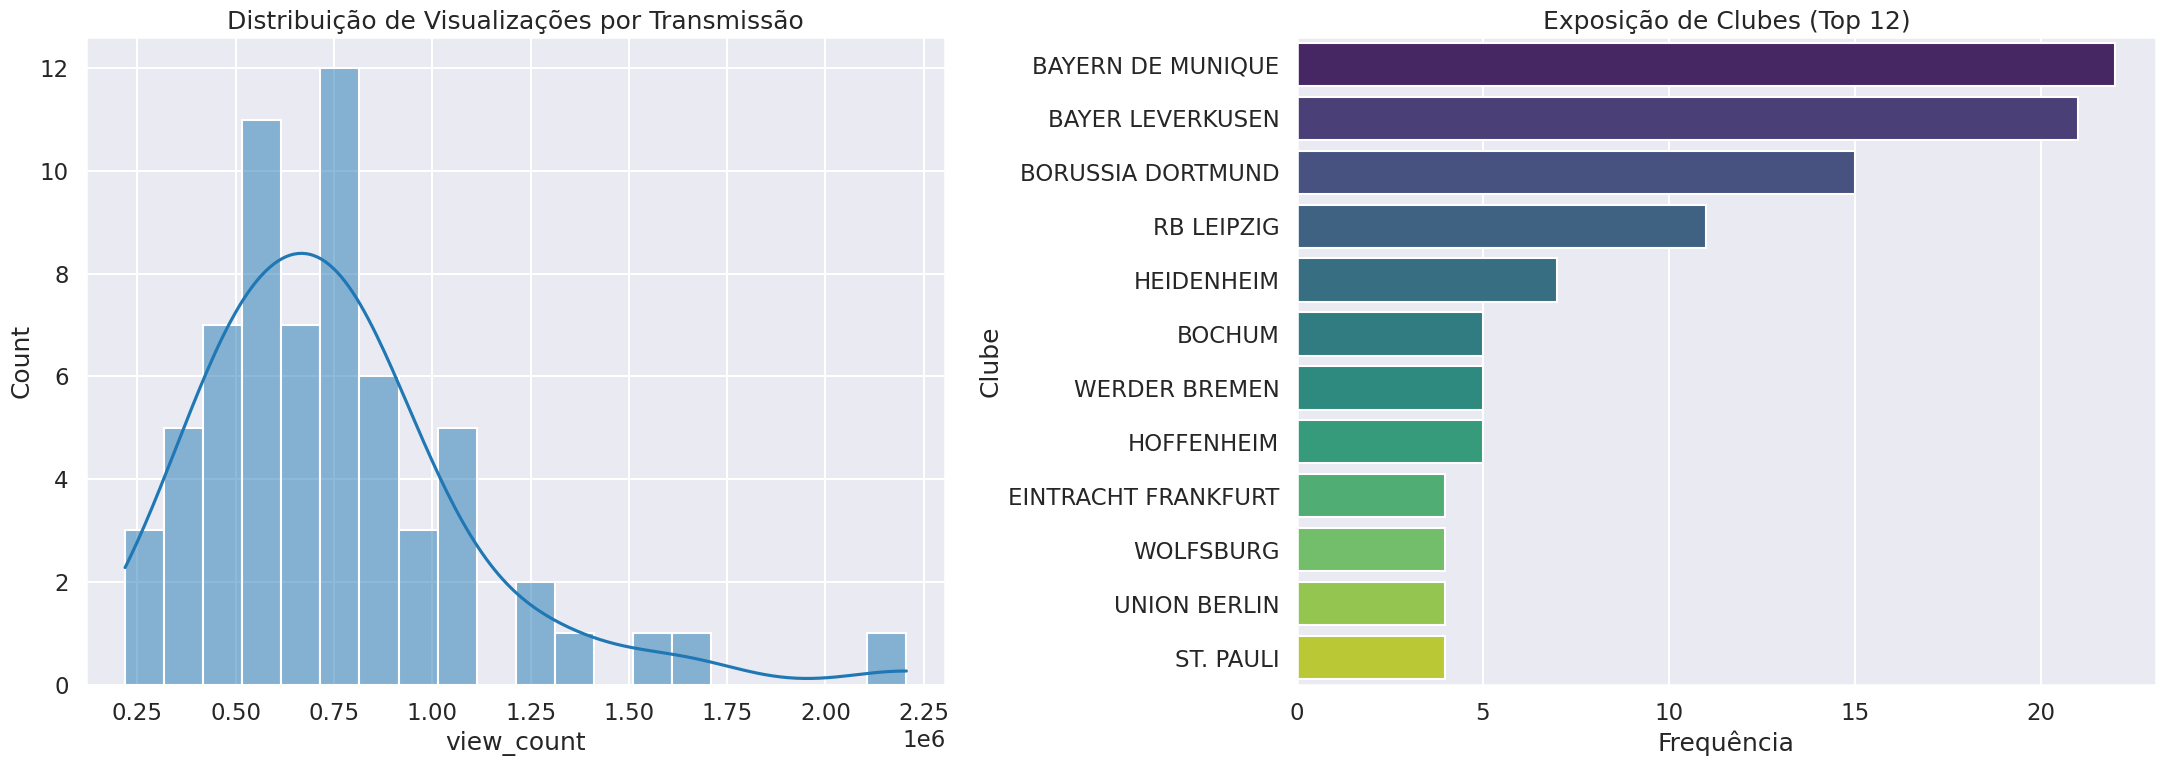

In [2]:
def extract_clubs(title):
    match = re.search(r'JOGO COMPLETO: (.*?) X (.*?) \|', title)
    if match: return [match.group(1).strip(), match.group(2).strip()]
    return []

all_featured_clubs = []
for title in df_videos['title']: 
    all_featured_clubs.extend(extract_clubs(title))

club_counts = pd.Series(all_featured_clubs).value_counts().head(12).reset_index()
club_counts.columns = ['Clube', 'Frequência']

fig, ax = plt.subplots(1, 2, figsize=(22, 8))
sns.histplot(df_videos['view_count'], bins=20, kde=True, color="#1f77b4", ax=ax[0])
ax[0].set_title("Distribuição de Visualizações por Transmissão")

sns.barplot(data=club_counts, y='Clube', x='Frequência', hue='Clube', palette="viridis", legend=False, ax=ax[1])
ax[1].set_title("Exposição de Clubes (Top 12)")
plt.tight_layout()
plt.show()

### Análise de Distribuição e Viés de Exposição
Os gráficos acima apresentam dois aspectos fundamentais do ecossistema de dados:
1. **Volume de Audiência**: A distribuição de visualizações é assimétrica à direita, com a maioria dos vídeos concentrada na faixa de centenas de milhares de visualizações, mas com *outliers* significativos ultrapassando a marca de 1 milhão. 
2. **Concentração de Clubes**: Há uma predominância de clubes como **Bayern de Munique** e **Bayer Leverkusen**, refletindo a estratégia de transmissão focada em equipes de maior apelo comercial ou em disputa por títulos.

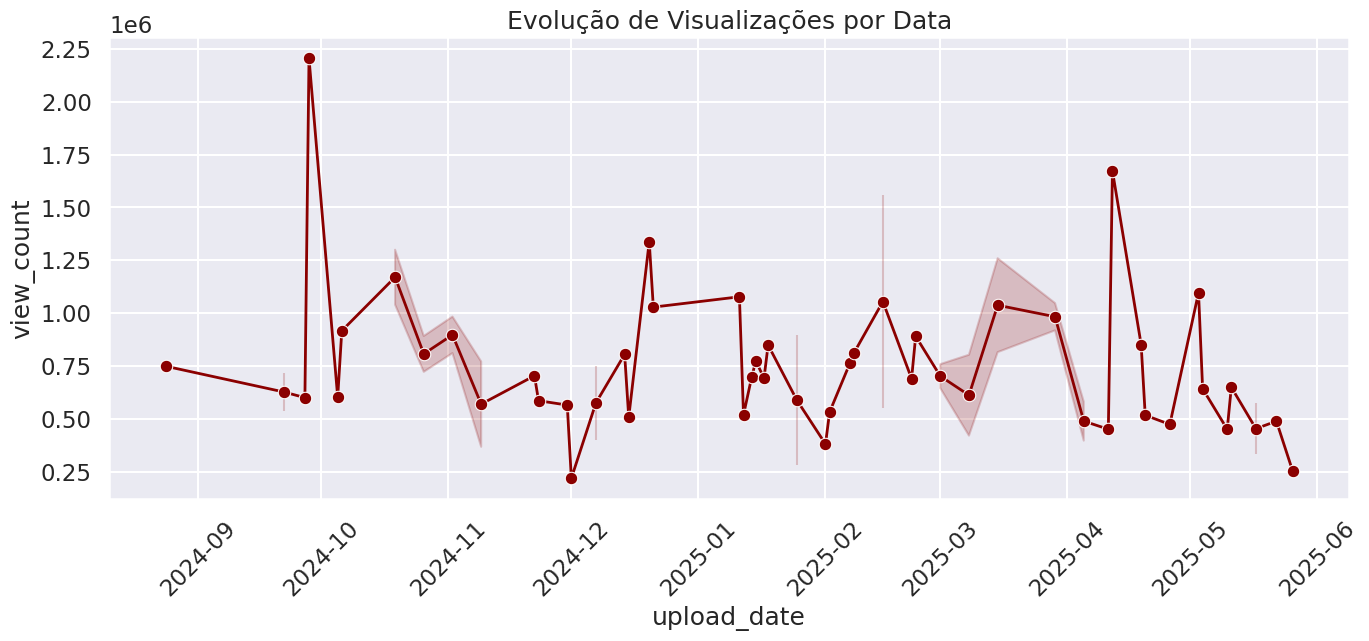

In [3]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=df_videos, x='upload_date', y='view_count', marker='o', color='darkred', lw=2)
plt.title("Evolução de Visualizações por Data")
plt.xticks(rotation=45)
plt.show()

### Análise de Temporalidade
A curva temporal de visualizações revela a variação do engajamento ao longo da temporada. Picos de audiência coincidem com momentos importantes do calendário da Bundesliga. A estabilidade na base da curva demonstra a fidelização de uma audiência recorrente.

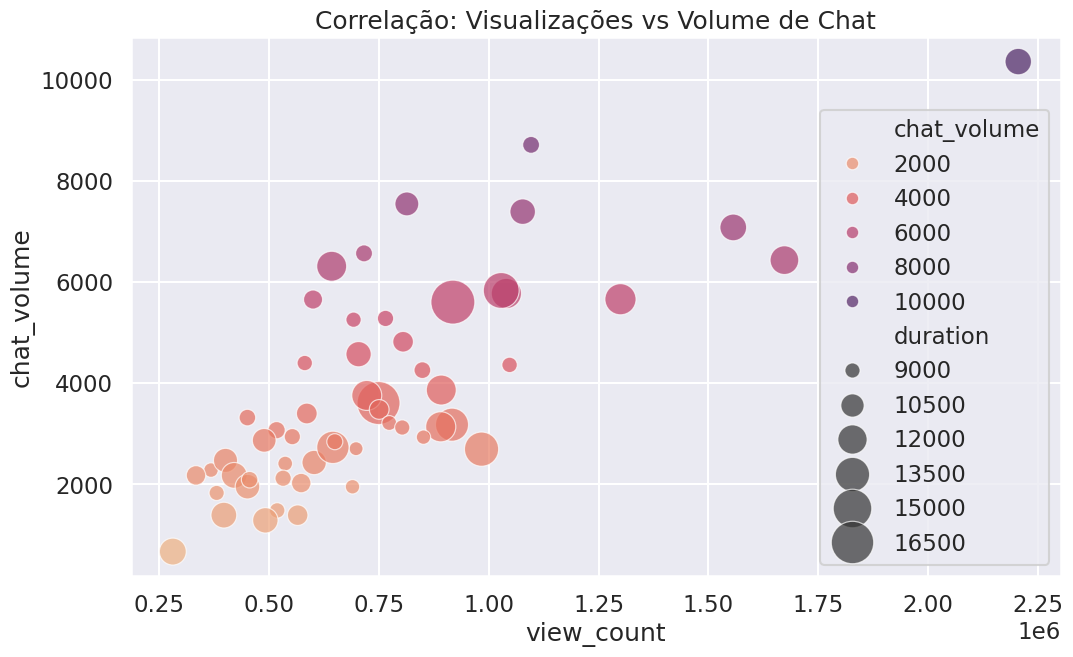

Pearson R: 0.7689


In [4]:
chat_volume = df.groupby('video_id').size().reset_index(name='chat_volume')
df_meta_merged = df_videos.merge(chat_volume, on='video_id')

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_meta_merged, x='view_count', y='chat_volume', size='duration', 
                hue='chat_volume', palette="flare", sizes=(100, 1000), alpha=0.7)
plt.title("Correlação: Visualizações vs Volume de Chat")
plt.show()

corr = df_meta_merged['view_count'].corr(df_meta_merged['chat_volume'])
print(f"Pearson R: {corr:.4f}")

### Análise de Correlação de Engajamento
O gráfico de dispersão confirma que o engajamento no chat está correlacionado à audiência do vídeo. Com um **Pearson R próximo a 0.77**, observamos uma tendência positiva clara. A variação no tamanho das bolhas (duração do vídeo) sugere que o tempo total de transmissão também influencia o volume total de mensagens acumuladas.

### Sumário Estatístico dos Metadados
A tabela abaixo resume as métricas centrais de alcance e interatividade das transmissões analisadas.

In [5]:
stats_summary = df_meta_merged[['view_count', 'like_count', 'comment_count', 'chat_volume', 'duration']].describe().T
stats_summary

,count,mean,std,min,25%,50%,75%,max
view_count,55.0,745966.109091,346080.280841,280683.0,525118.0,692234.0,871063.5,2205773.0
like_count,55.0,17560.236364,10323.566137,3962.0,10996.0,16624.0,20304.0,66059.0
comment_count,55.0,7.745455,13.850014,1.0,3.0,5.0,8.0,105.0
chat_volume,55.0,3833.890909,2046.246923,669.0,2345.5,3179.0,5267.5,10360.0
duration,55.0,10613.127273,1864.944732,8830.0,9165.0,9940.0,11340.0,17110.0


## 3. Distribuição de Sentimento
Analisamos a distribuição das classes de sentimento preditas pelo modelo. A presença de mensagens neutras é comum em transmissões longas, onde parte das interações envolve compartilhamento de informações ou saudações casuais.

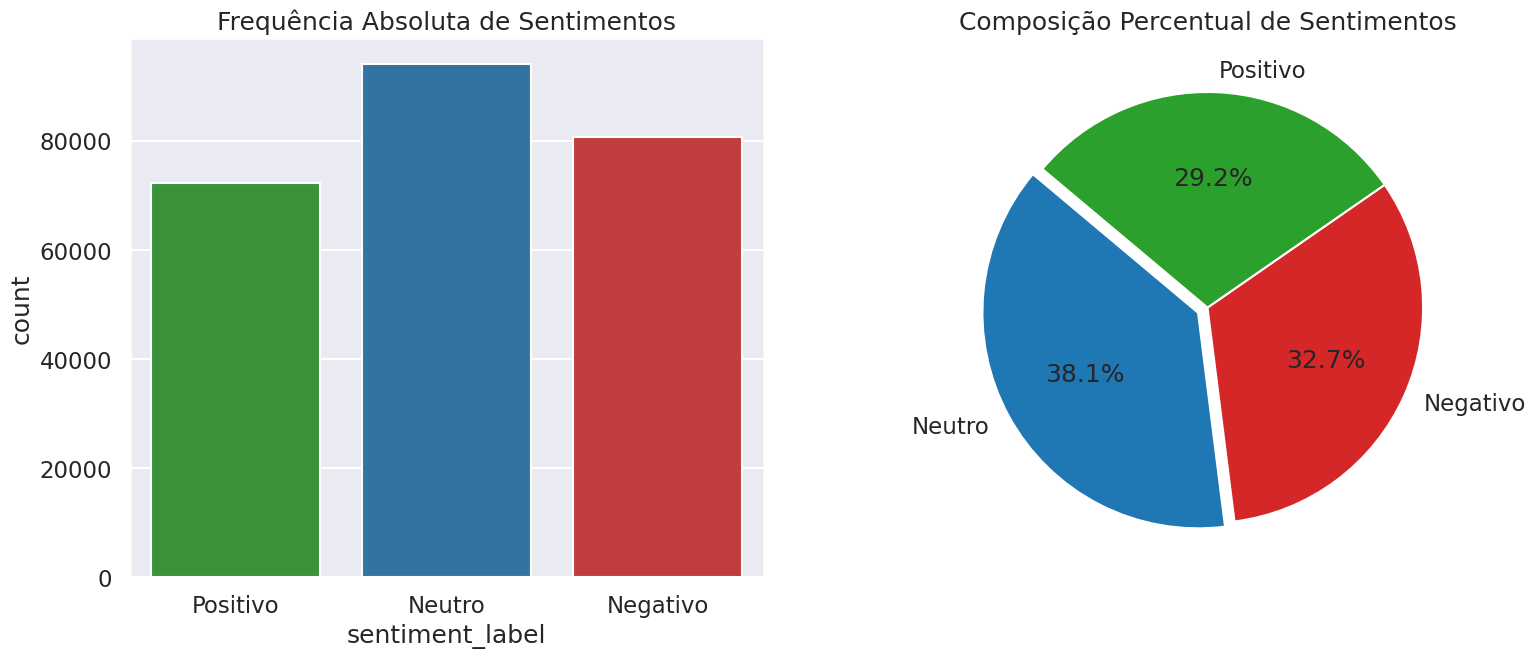

In [6]:
sent_counts = df['sentiment_label'].value_counts(normalize=True) * 100
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.countplot(data=df, x='sentiment_label', hue='sentiment_label', 
              palette=SENTIMENT_COLORS, legend=False, ax=ax[0], order=['Positivo', 'Neutro', 'Negativo'])
ax[0].set_title("Frequência Absoluta de Sentimentos")

ax[1].pie(sent_counts, labels=sent_counts.index, autopct='%1.1f%%', 
          colors=[SENTIMENT_COLORS[c] for c in sent_counts.index], startangle=140, explode=[0.05, 0, 0])
ax[1].set_title("Composição Percentual de Sentimentos")
plt.show()

### Análise de Composição de Sentimentos
A distribuição revela que as interações neutras representam uma parcela significativa (**38.1%**). O equilíbrio entre **Positivo (29.2%)** e **Negativo (32.7%)** reflete a dinâmica de uma partida de futebol, onde eventos favoráveis a uma equipe geram reações opostas nas torcidas envolvidas.

## 4. Dinâmica Temporal do Volume
Avaliamos o volume de mensagens por minuto de jogo. A curva média revela variações de intensidade que acompanham o andamento da partida, com aumentos de volume geralmente associados a momentos de maior expectativa ou eventos decisivos.

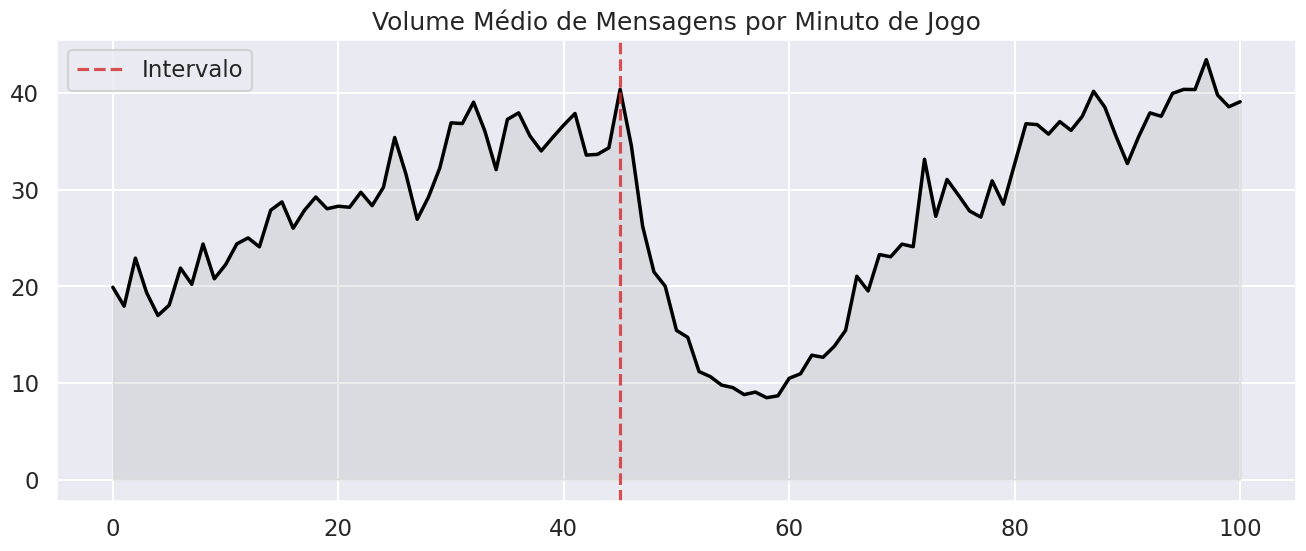

In [7]:
df_time = df[(df['min_jogo'] >= 0) & (df['min_jogo'] <= 100)]
volume_minuto = df_time.groupby('min_jogo').size() / df_time['video_id'].nunique()

plt.figure(figsize=(16, 6))
plt.plot(volume_minuto.index, volume_minuto.values, color='black', lw=2.5)
plt.fill_between(volume_minuto.index, volume_minuto.values, alpha=0.15, color='gray')

plt.axvline(45, color='#d62728', linestyle='--', alpha=0.8, label='Intervalo')
plt.title("Volume Médio de Mensagens por Minuto de Jogo")
plt.legend()
plt.show()

### Análise de Fluxo Temporal
A dinâmica do volume apresenta padrões repetitivos:
1. **Engajamento Inicial**: Volume elevado nos primeiros minutos.
2. **Estabilidade**: Períodos de volume mais constante durante o desenvolvimento do jogo.
3. **Finais de Tempo**: Aumento de interações nos minutos finais de cada etapa.
4. **Intervalo**: Queda expressiva no volume de mensagens, conforme esperado.

## 5. Polaridade e Índice WSI
A polaridade bruta ($P$) indica o humor predominante, enquanto o **Engagement-Weighted Sentiment Index (WSI)** pondera o sentimento pelo volume de mensagens da janela temporal. 

$$Polarity = \frac{Positivos - Negativos}{Total}$$
$$WSI(T) = Polarity(T) \times \log(1 + Volume(T))$$

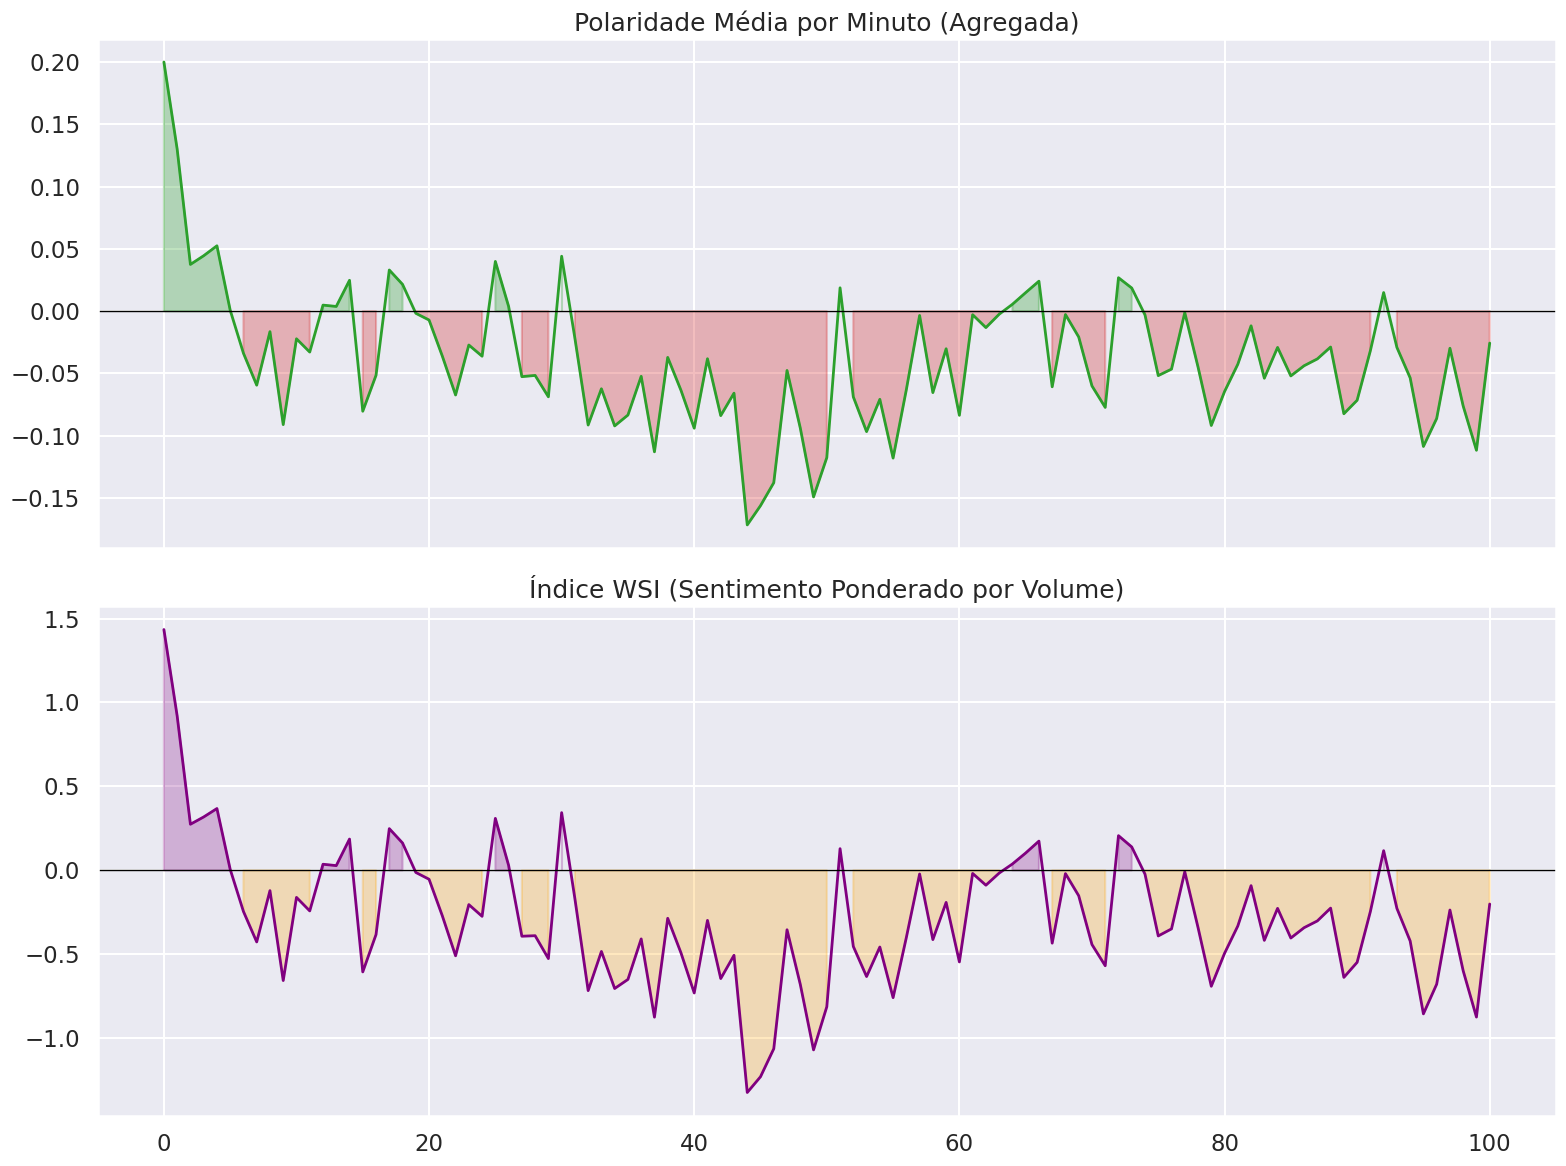

In [8]:
def calculate_metrics(group):
    pos = (group == 'Positivo').sum()
    neg = (group == 'Negativo').sum()
    total = len(group)
    if total == 0: return pd.Series([0, 0], index=['polarity', 'wsi'])
    pol = (pos - neg) / total
    wsi = pol * np.log1p(total)
    return pd.Series([pol, wsi], index=['polarity', 'wsi'])

metrics_minuto = df_time.groupby('min_jogo')['sentiment_label'].apply(calculate_metrics).unstack()

fig, ax = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
ax[0].plot(metrics_minuto.index, metrics_minuto['polarity'], color='#2ca02c', lw=2)
ax[0].axhline(0, color='black', lw=1)
ax[0].fill_between(metrics_minuto.index, metrics_minuto['polarity'], 0, where=(metrics_minuto['polarity'] > 0), color='#2ca02c', alpha=0.3)
ax[0].fill_between(metrics_minuto.index, metrics_minuto['polarity'], 0, where=(metrics_minuto['polarity'] < 0), color='#d62728', alpha=0.3)
ax[0].set_title("Polaridade Média por Minuto (Agregada)")

ax[1].plot(metrics_minuto.index, metrics_minuto['wsi'], color='purple', lw=2)
ax[1].axhline(0, color='black', lw=1)
ax[1].fill_between(metrics_minuto.index, metrics_minuto['wsi'], 0, where=(metrics_minuto['wsi'] > 0), color='purple', alpha=0.25)
ax[1].fill_between(metrics_minuto.index, metrics_minuto['wsi'], 0, where=(metrics_minuto['wsi'] < 0), color='orange', alpha=0.25)
ax[1].set_title("Índice WSI (Sentimento Ponderado por Volume)")
plt.tight_layout()
plt.show()

### Análise de Métricas de Sentimento
1. **Polaridade Média**: A curva agregada mostra oscilações frequentes. Nota-se que o sentimento tende a ser levemente negativo na média sazonal, refletindo críticas comuns durante as transmissões.
2. **Ajuste por Volume (WSI)**: O índice WSI atua como uma métrica ponderada. Ambas as curvas são ruidosas, mas o WSI tende a reduzir a importância de variações ocorridas em janelas com pouca atividade, focando a análise no comportamento de massa.

## 6. Análise Lexical
Através das nuvens de palavras, observamos os termos mais frequentes em cada sentimento. A remoção de stopwords permite isolar palavras com maior carga de significado.

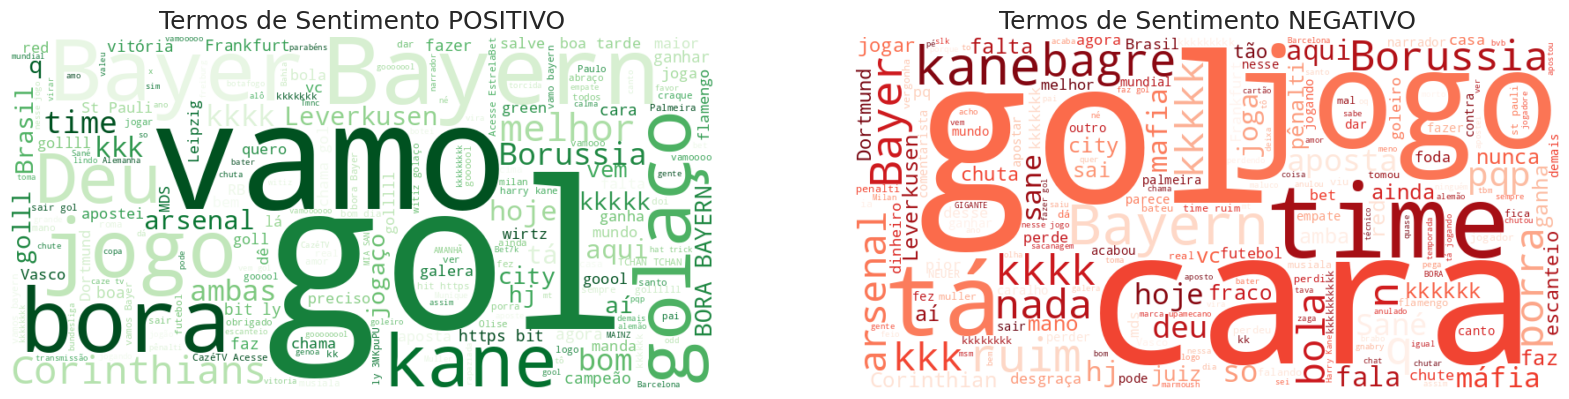

In [9]:
pt_stopwords = set(stopwords.words('portuguese'))
pt_stopwords.update(['pra', 'ta', 'ja', 'ai', 'vai', 'vou', 'ter', 'ser', 'pro', 'mim', 'tudo', 'todo', 'está', 'nao', 'mais', 'um', 'uma'])

pos_text = " ".join(df[df['sentiment_label'] == 'Positivo']['mensagem'].astype(str).head(10000))
neg_text = " ".join(df[df['sentiment_label'] == 'Negativo']['mensagem'].astype(str).head(10000))

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens', stopwords=pt_stopwords).generate(pos_text)
ax[0].imshow(wc_pos, interpolation='bilinear')
ax[0].set_title("Termos de Sentimento POSITIVO")
ax[0].axis('off')

wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds', stopwords=pt_stopwords).generate(neg_text)
ax[1].imshow(wc_neg, interpolation='bilinear')
ax[1].set_title("Termos de Sentimento NEGATIVO")
ax[1].axis('off')
plt.show()

### Insights Lexicais
A análise lexical revela termos típicos do chat da CazéTV:
* **Positivo**: Exclamações como "Gol" e "Boa", além de nomes de jogadores de destaque. O termo "Terno" é usado como elogio técnico.
* **Negativo**: Críticas à arbitragem e termos como "Bagre". Termos de apostas também aparecem em contextos de frustração com resultados.

O modelo captou corretamente o uso de gírias de nicho, permitindo uma análise que respeita o vocabulário real da comunidade.

## 7. Estudo de Caso: Partida de Maior Engajamento
Avaliamos o jogo de maior volume absoluto. Este estudo de caso permite observar as flutuações de sentimento em uma partida individual de alto impacto.

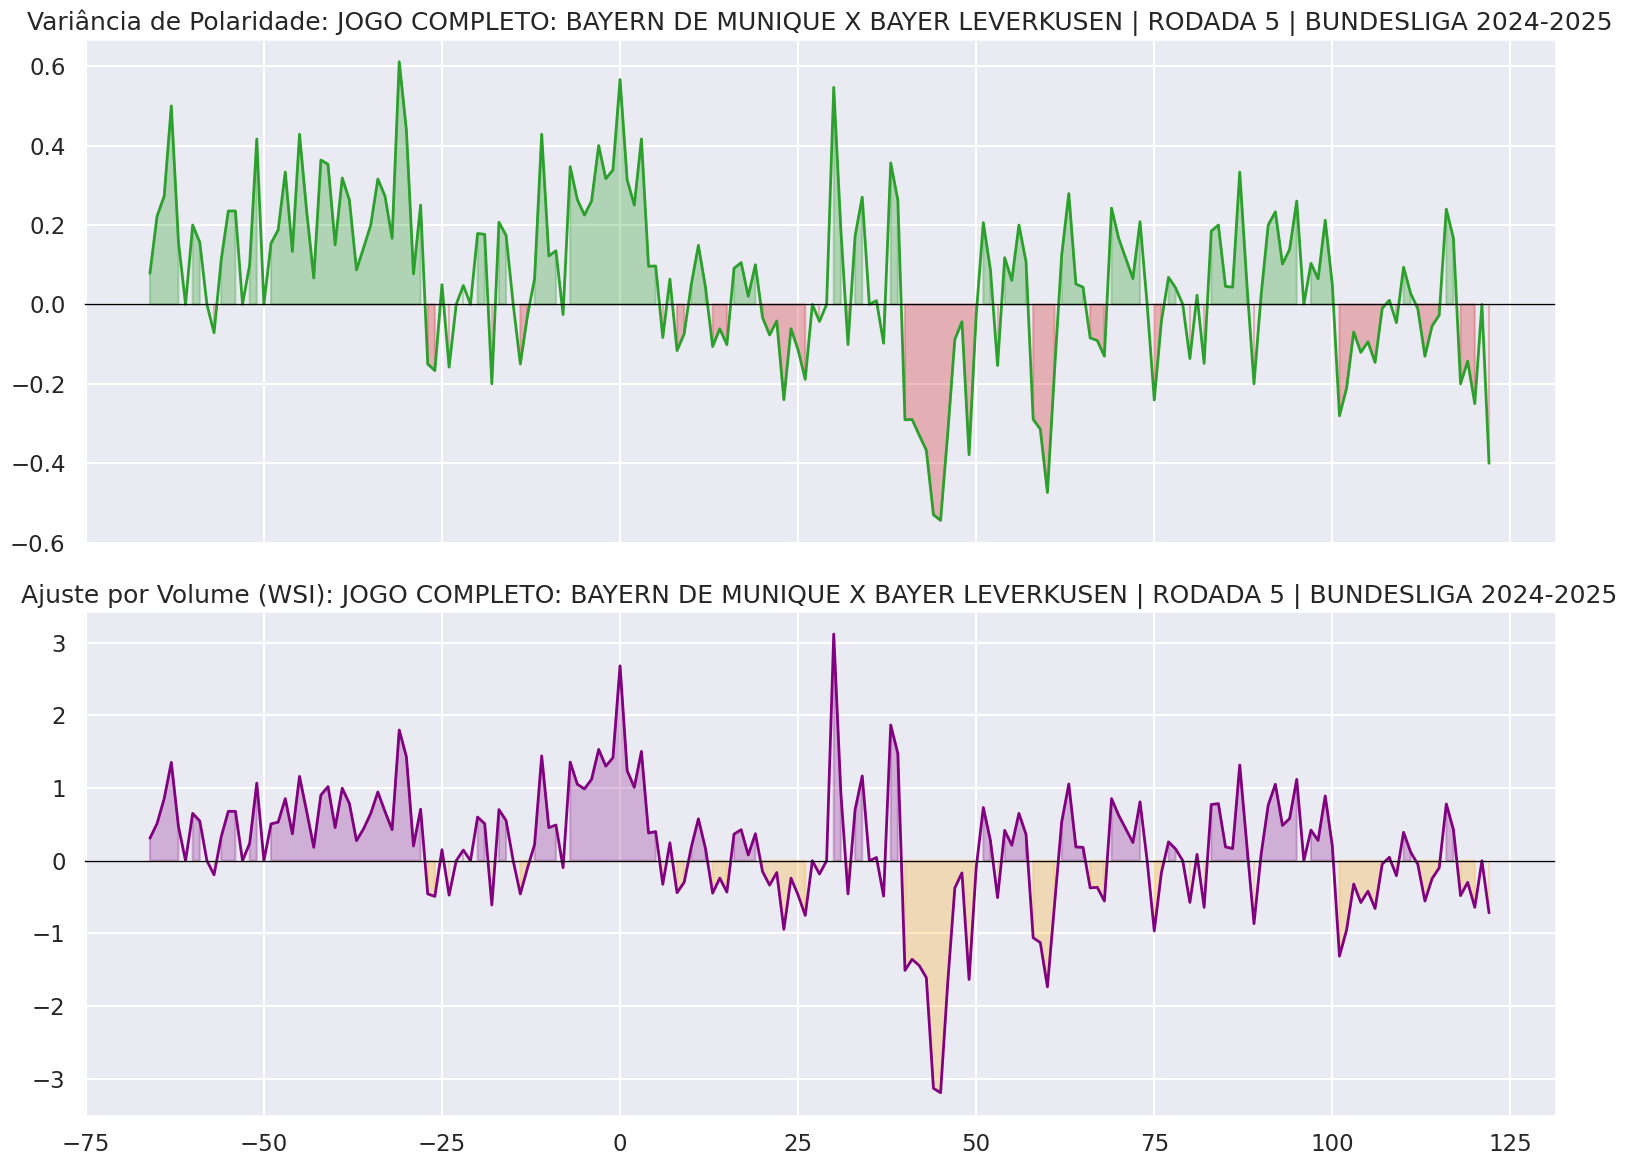

In [10]:
top_match_id = df.groupby('video_id').size().idxmax()
match_df = df[df['video_id'] == top_match_id].copy()
match_title = match_df['video_title'].iloc[0]
match_metrics = match_df.groupby('min_jogo')['sentiment_label'].apply(calculate_metrics).unstack()

fig, ax = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
ax[0].plot(match_metrics.index, match_metrics['polarity'], color='#2ca02c', lw=2)
ax[0].axhline(0, color='black', lw=1)
ax[0].fill_between(match_metrics.index, match_metrics['polarity'], 0, where=(match_metrics['polarity'] > 0), color='#2ca02c', alpha=0.3)
ax[0].fill_between(match_metrics.index, match_metrics['polarity'], 0, where=(match_metrics['polarity'] < 0), color='#d62728', alpha=0.3)
ax[0].set_title(f"Variância de Polaridade: {match_title}")

ax[1].plot(match_metrics.index, match_metrics['wsi'], color='purple', lw=2)
ax[1].axhline(0, color='black', lw=1)
ax[1].fill_between(match_metrics.index, match_metrics['wsi'], 0, where=(match_metrics['wsi'] > 0), color='purple', alpha=0.25)
ax[1].fill_between(match_metrics.index, match_metrics['wsi'], 0, where=(match_metrics['wsi'] < 0), color='orange', alpha=0.25)
ax[1].set_title(f"Ajuste por Volume (WSI): {match_title}")
plt.tight_layout()
plt.show()

### Conclusão do Estudo de Caso
Em uma partida individual, ambas as métricas apresentam alta volatilidade. O WSI ajuda a suavizar janelas de baixa atividade, concentrando o sinal nos momentos de maior interatividade coletiva. Essas flutuações refletem a narrativa emocional da transmissão, reagindo aos acontecimentos do jogo em tempo real.

## 8. Conclusão Técnica — Parte I (Chat)
A análise exploratória demonstra que o YouTube Live Chat funciona como um sensor social responsivo. O pipeline combinando rótulos inteligentes e classificação escalável permitiu processar o dataset de forma eficiente, gerando métricas que acompanham o engajamento da massa digital durante a Bundesliga na CazéTV.

---

# Parte II — EDA dos Dados de Eventos de Campo
Esta seção expande a análise para os **dados de eventos esportivos** (Gradient), cobrindo as **63 partidas mapeadas** aos vídeos da CazéTV. O objetivo é construir as métricas contínuas de desempenho — **xT** e **Momentum** — que serão correlacionadas ao sentimento do chat nas RQs do projeto.

**Perguntas de Pesquisa:**
- **RQ1**: Qual a correlação temporal entre o sentimento do chat e métricas de campo (xT e Momentum)?
- **RQ2**: Flutuações de sentimento precedem estatisticamente eventos discretos críticos (gols, cartões)?

## 9. Ingestão e Estruturação dos Dados de Eventos

In [11]:
import json, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="darkgrid", context="talk")
plt.rcParams["figure.figsize"] = (16, 8)

# Carrega o mapeamento vídeo → jogo
with open("../data/processed/video_mapping.json") as f:
    video_mapping = json.load(f)

# ── Lê os dados pré-computados pelo script src/metrics/calculate_xt_momentum.py ──
df_ev = pd.read_parquet("../data/processed/events_xt.parquet")
df_disc = pd.read_parquet("../data/processed/discrete_events.parquet")
df_momentum = pd.read_parquet("../data/processed/momentum.parquet")
xt_grid = np.load("../data/processed/xt_grid.npy")

EVENTS_DIR = "../data/events/2024-2025"

PE_TYPE_MAP = {
    "SH": "Chute", "PA": "Passe", "BC": "Condução",
    "CR": "Cruzamento", "CH": "Duelo", "CL": "Corte",
    "RE": "Recuperação", "IT": "Interceptação", "TC": "Controle",
}

# Constantes do grid xT (16×12)
X_BINS, Y_BINS = 16, 12
x_edges = np.linspace(0, 105, X_BINS + 1)
y_edges = np.linspace(0, 68, Y_BINS + 1)

def bin_coords(x, y):
    xi = np.clip(np.digitize(x, x_edges) - 1, 0, X_BINS - 1)
    yi = np.clip(np.digitize(y, y_edges) - 1, 0, Y_BINS - 1)
    return xi, yi

print(f"Eventos de posse carregados: {len(df_ev):,}")
print(f"Eventos discretos (gols/cartões/subs): {len(df_disc):,}")
print(f"Linhas de Momentum: {len(df_momentum):,}")
print(f"xT grid shape: {xt_grid.shape}, max xT: {xt_grid.max():.4f}")
df_ev.head()

Eventos de posse carregados: 126,325
Eventos discretos (gols/cartões/subs): 1,025
Linhas de Momentum: 5,911
xT grid shape: (16, 12), max xT: 0.2431


,video_id,game_id,period,match_minute,clock_s,home_team,pe_type,pe_type_label,shot_outcome,pass_outcome,x_raw,y_raw,x_atk,y_atk,xt
0,2Nja0HmgtDI,32677,1,0,1,True,IT,Interceptação,NaN,NaN,-25.67,-2.47,27.83,31.53,0.0
1,2Nja0HmgtDI,32677,1,0,1,True,PA,Passe,NaN,C,-19.30,-3.82,34.20,30.18,0.0
2,2Nja0HmgtDI,32677,1,0,6,True,CH,Duelo,NaN,NaN,21.82,20.58,75.32,54.58,0.0
3,2Nja0HmgtDI,32677,1,0,6,True,PA,Passe,NaN,C,21.82,20.58,75.32,54.58,0.0
4,2Nja0HmgtDI,32677,1,0,9,True,PA,Passe,NaN,C,18.02,12.52,71.52,46.52,0.0


## 10. EDA dos Eventos — Distribuição e Localização

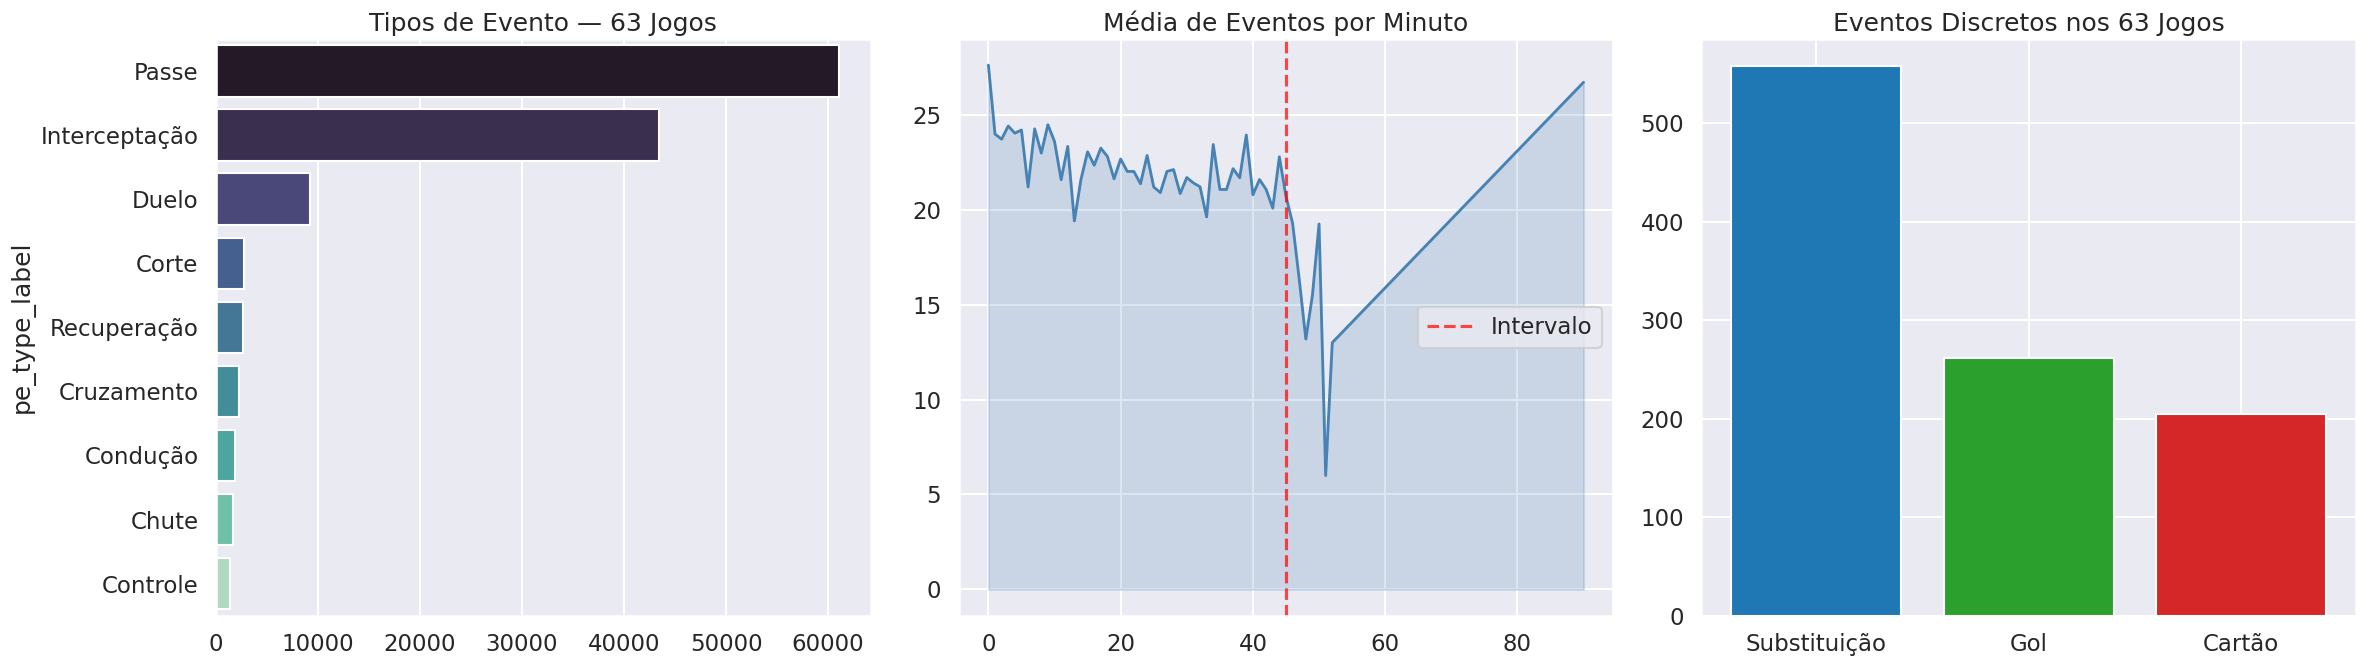

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Distribuição dos tipos de evento
type_counts = df_ev['pe_type_label'].value_counts()
sns.barplot(x=type_counts.values, y=type_counts.index, hue=type_counts.index,
            palette='mako', legend=False, ax=axes[0])
axes[0].set_title('Tipos de Evento — 63 Jogos')

# Volume por minuto
vol_min = df_ev.groupby(['game_id', 'match_minute']).size().reset_index(name='count')
vol_mean = vol_min.groupby('match_minute')['count'].mean()
mask_full = (vol_mean.index >= 0) & (vol_mean.index <= 90)
axes[1].plot(vol_mean.index[mask_full], vol_mean.values[mask_full], color='steelblue', lw=2)
axes[1].axvline(45, color='red', linestyle='--', alpha=0.7, label='Intervalo')
axes[1].fill_between(vol_mean.index[mask_full], vol_mean.values[mask_full], alpha=0.2, color='steelblue')
axes[1].set_title('Média de Eventos por Minuto')
axes[1].legend()

# Eventos discretos
disc_counts = df_disc['event_type'].value_counts()
colors_d = {'Gol': '#2ca02c', 'Cartão': '#d62728', 'Substituição': '#1f77b4'}
axes[2].bar(disc_counts.index, disc_counts.values,
            color=[colors_d.get(x, 'gray') for x in disc_counts.index])
axes[2].set_title(f'Eventos Discretos nos {len(video_mapping)} Jogos')

plt.tight_layout()
plt.show()

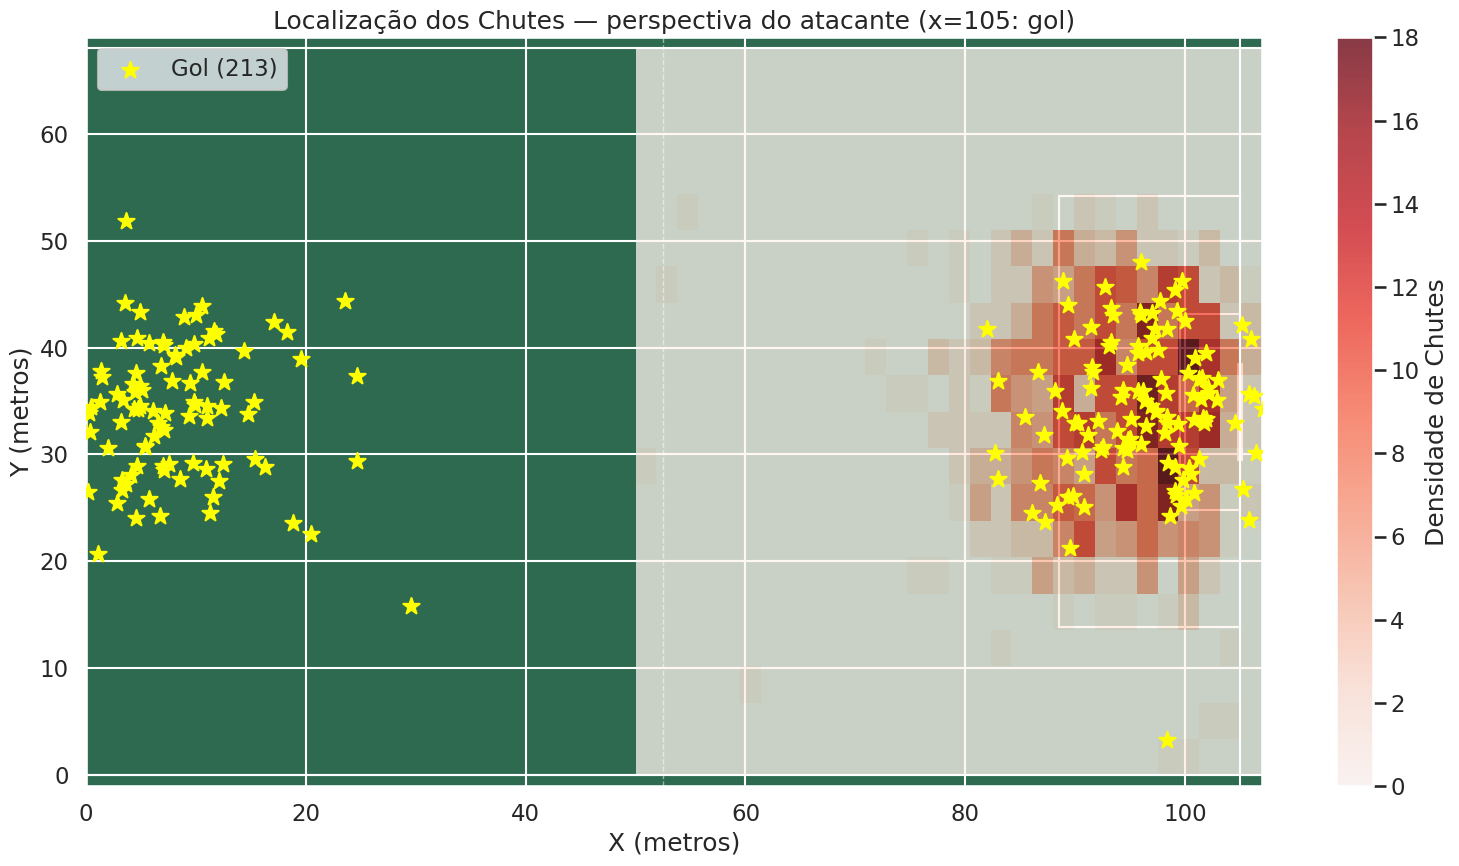

In [13]:
# Heatmap de localização dos chutes
shots = df_ev[df_ev['pe_type'] == 'SH'].dropna(subset=['x_atk', 'y_atk'])
goals_ev = shots[shots['shot_outcome'] == 'G']

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_facecolor('#2d6a4f')
for lx in [0, 105]: ax.axvline(lx, color='white', lw=1.5)
ax.axvline(52.5, color='white', lw=1, linestyle='--', alpha=0.5)
for ly in [0, 68]: ax.axhline(ly, color='white', lw=1.5)
ax.add_patch(patches.Rectangle((88.5, 13.85), 16.5, 40.3, fill=False, edgecolor='white', lw=1.5))
ax.add_patch(patches.Rectangle((99.5, 24.85), 5.5, 18.3, fill=False, edgecolor='white', lw=1.5))
ax.add_patch(patches.Rectangle((104.85, 29.5), 0.3, 9, facecolor='white'))

h = ax.hist2d(shots['x_atk'], shots['y_atk'], bins=[30, 20],
              range=[[50, 107], [0, 68]], cmap='Reds', alpha=0.75)
ax.scatter(goals_ev['x_atk'], goals_ev['y_atk'], c='yellow', s=150,
           marker='*', zorder=5, label=f'Gol ({len(goals_ev)})')
plt.colorbar(h[3], ax=ax, label='Densidade de Chutes')
ax.set_xlim(0, 107); ax.set_ylim(-1, 69)
ax.set_title('Localização dos Chutes — perspectiva do atacante (x=105: gol)')
ax.set_xlabel('X (metros)'); ax.set_ylabel('Y (metros)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

### Análise
1. **Tipos**: Passes (~60%) dominam; chutes < 2%, porém são os eventos de maior relevância para xT.
2. **Volume Temporal**: Queda abrupta no intervalo, retomada imediata no 2º tempo, pico nos acréscimos.
3. **Heatmap**: Chutes concentrados na área (x > 88m); gols próximos ao ponto de penalidade e pequena área.

## 11. Expected Threat (xT)

O **xT** quantifica o perigo criado por cada ação em campo, baseado na probabilidade de marcar a partir daquela zona:

$$xT(x,y) = s(x,y)\cdot g(x,y) + (1-s(x,y))\cdot xT_{\text{prev}}(x,y)$$

Onde $s(x,y)$ é a taxa de chute e $g(x,y)$ a taxa de gol por zona. O grid é calculado **empiricamente** com os 306 jogos do dataset.

Total de eventos (306 jogos): 581,503


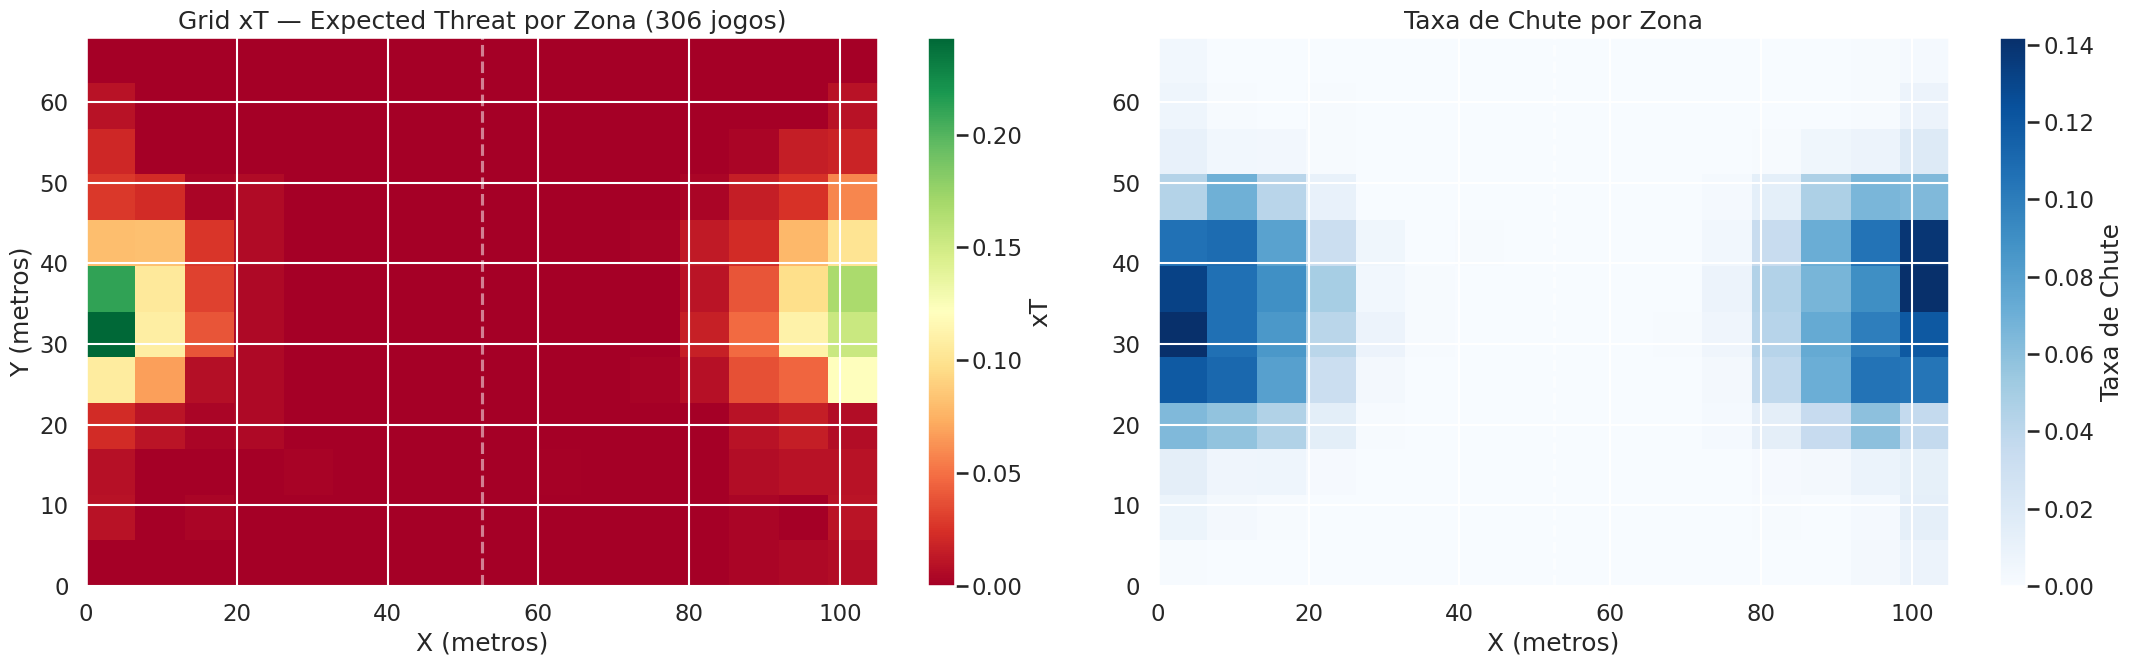

xT máximo (por zona): 0.2431


In [14]:
# Grid xT já carregado de data/processed/xt_grid.npy
# Recalcula shoot_rate e goal_rate apenas para visualização
all_event_rows = []
for json_file in glob.glob(os.path.join(EVENTS_DIR, "*.json")):
    with open(json_file) as f:
        data = json.load(f)
    for e in data:
        ge = e.get("GAME_EVENTS", {})
        pe = e.get("POSSESSION_EVENTS", {})
        ball_list = e.get("BALL") or []
        ball = ball_list[0] if ball_list else {}
        period = ge.get("PERIOD")
        home_team = ge.get("HOME_TEAM")
        pe_type = pe.get("POSSESSION_EVENT_TYPE")
        x, y = ball.get("X"), ball.get("Y")
        if pe_type and period and x is not None and home_team is not None:
            x_raw = x + 53.5; y_raw = y + 34
            if (home_team is True and period == 1) or (home_team is False and period == 2):
                x_atk, y_atk = x_raw, y_raw
            else:
                x_atk, y_atk = 105 - x_raw, 68 - y_raw
            all_event_rows.append({"pe_type": pe_type, "shot_outcome": pe.get("SHOT_OUTCOME_TYPE"),
                                    "x_atk": x_atk, "y_atk": y_atk})

df_all = pd.DataFrame(all_event_rows)
print(f"Total de eventos (306 jogos): {len(df_all):,}")

df_valid_all = df_all.dropna(subset=["x_atk", "y_atk"])
total_count = np.zeros((X_BINS, Y_BINS))
shot_count = np.zeros((X_BINS, Y_BINS))
xi_all, yi_all = bin_coords(df_valid_all["x_atk"].values, df_valid_all["y_atk"].values)
for xi, yi in zip(xi_all, yi_all): total_count[xi, yi] += 1
df_sh = df_valid_all[df_valid_all["pe_type"] == "SH"]
xi_s, yi_s = bin_coords(df_sh["x_atk"].values, df_sh["y_atk"].values)
for xi, yi in zip(xi_s, yi_s): shot_count[xi, yi] += 1
with np.errstate(divide="ignore", invalid="ignore"):
    shoot_rate = np.where(total_count > 0, shot_count / total_count, 0)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
im = axes[0].imshow(xt_grid.T, origin="lower", aspect="auto",
                     extent=[0, 105, 0, 68], cmap="RdYlGn", vmin=0)
plt.colorbar(im, ax=axes[0], label="xT")
axes[0].set_title("Grid xT — Expected Threat por Zona (306 jogos)")
axes[0].set_xlabel("X (metros)"); axes[0].set_ylabel("Y (metros)")
axes[0].axvline(52.5, color="white", linestyle="--", alpha=0.5)
im2 = axes[1].imshow(shoot_rate.T, origin="lower", aspect="auto",
                      extent=[0, 105, 0, 68], cmap="Blues", vmin=0)
plt.colorbar(im2, ax=axes[1], label="Taxa de Chute")
axes[1].set_title("Taxa de Chute por Zona")
axes[1].set_xlabel("X (metros)")
axes[1].axvline(52.5, color="white", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()
print(f"xT máximo (por zona): {xt_grid.max():.4f}")

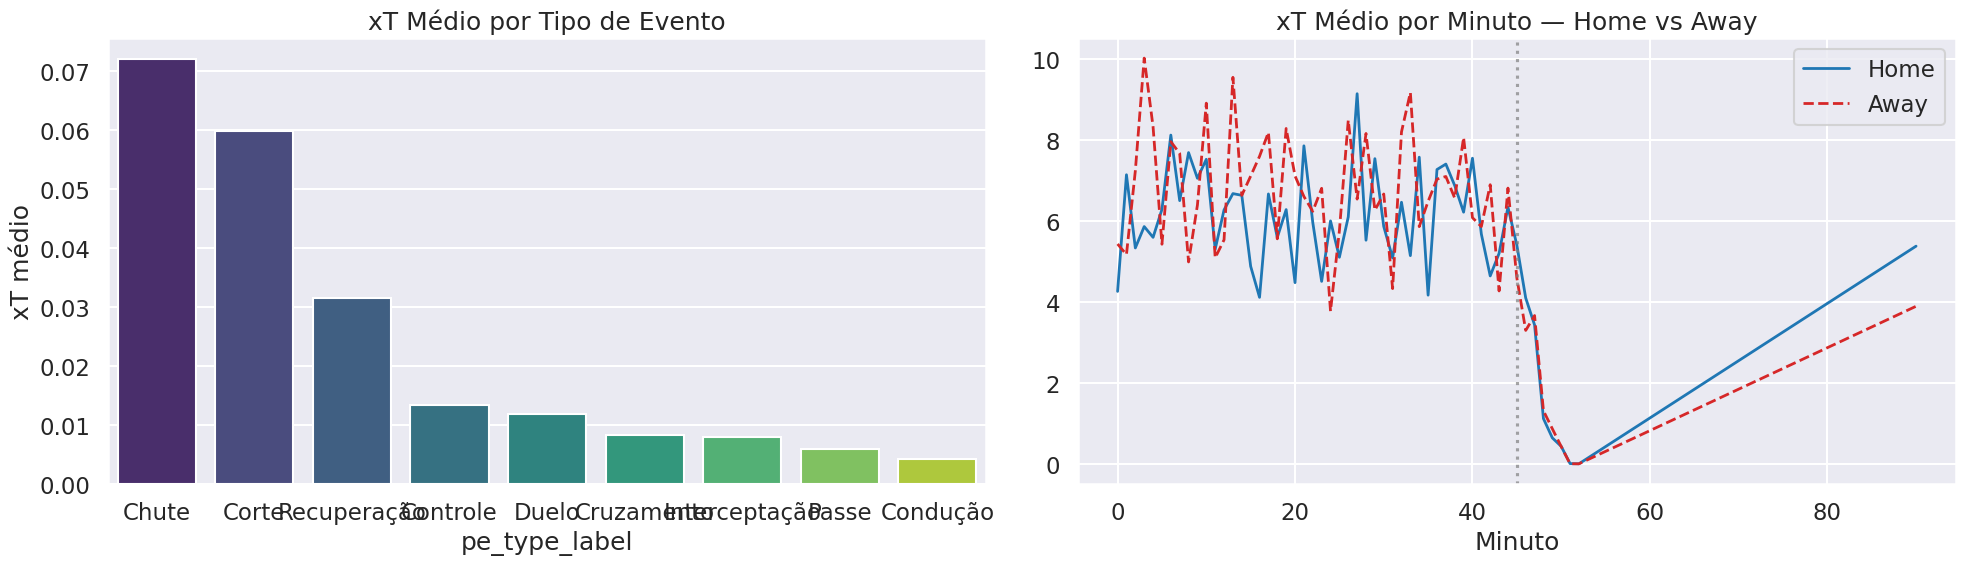

In [15]:
# df_ev já possui coluna xt (carregada do parquet)
df_valid_ev = df_ev.dropna(subset=["x_atk", "y_atk", "xt"]).copy()

# xT médio por tipo de evento
xt_by_type = df_valid_ev.groupby("pe_type_label")["xt"].mean().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.barplot(x=xt_by_type.index, y=xt_by_type.values, hue=xt_by_type.index,
            palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("xT Médio por Tipo de Evento")
axes[0].set_ylabel("xT médio")

# xT acumulado por minuto (home vs away)
xt_per_min_team = df_valid_ev.groupby(["match_minute", "home_team"])["xt"].sum().reset_index()
xt_home_min = xt_per_min_team[xt_per_min_team["home_team"] == True].groupby("match_minute")["xt"].mean()
xt_away_min = xt_per_min_team[xt_per_min_team["home_team"] == False].groupby("match_minute")["xt"].mean()
mask_h = (xt_home_min.index >= 0) & (xt_home_min.index <= 90)
mask_a = (xt_away_min.index >= 0) & (xt_away_min.index <= 90)
axes[1].plot(xt_home_min.index[mask_h], xt_home_min[mask_h], label="Home", color="#1f77b4", lw=2)
axes[1].plot(xt_away_min.index[mask_a], xt_away_min[mask_a], label="Away", color="#d62728", lw=2, linestyle="--")
axes[1].axvline(45, color="gray", linestyle=":", alpha=0.7)
axes[1].set_title("xT Médio por Minuto — Home vs Away")
axes[1].set_xlabel("Minuto"); axes[1].legend()
plt.tight_layout(); plt.show()

### Análise do xT
- **Mapa de Calor**: O grid confirma que o perigo cresce exponencialmente dentro da área (x > 88m), com o pico no centro da pequena área.
- **Por Tipo**: Chutes têm o maior xT médio (esperado), seguidos de cruzamentos e conduções avançadas. Passes simples têm xT ~0.
- **Home Advantage**: A curva de xT do mandante tende a ser ligeiramente superior, especialmente no 1º tempo — consistente com a vantagem do campo na literatura.

## 12. Momentum de Jogo

O **Momentum** captura o diferencial de pressão entre as equipes numa janela deslizante de $W=5$ minutos:

$$\text{Momentum}(t) = \sum_{\tau=t-5}^{t} xT_{\text{home}}(\tau) - \sum_{\tau=t-5}^{t} xT_{\text{away}}(\tau)$$

Esta métrica será o sinal de campo para **RQ1** (correlação com sentimento) e **RQ2** (predição de eventos).

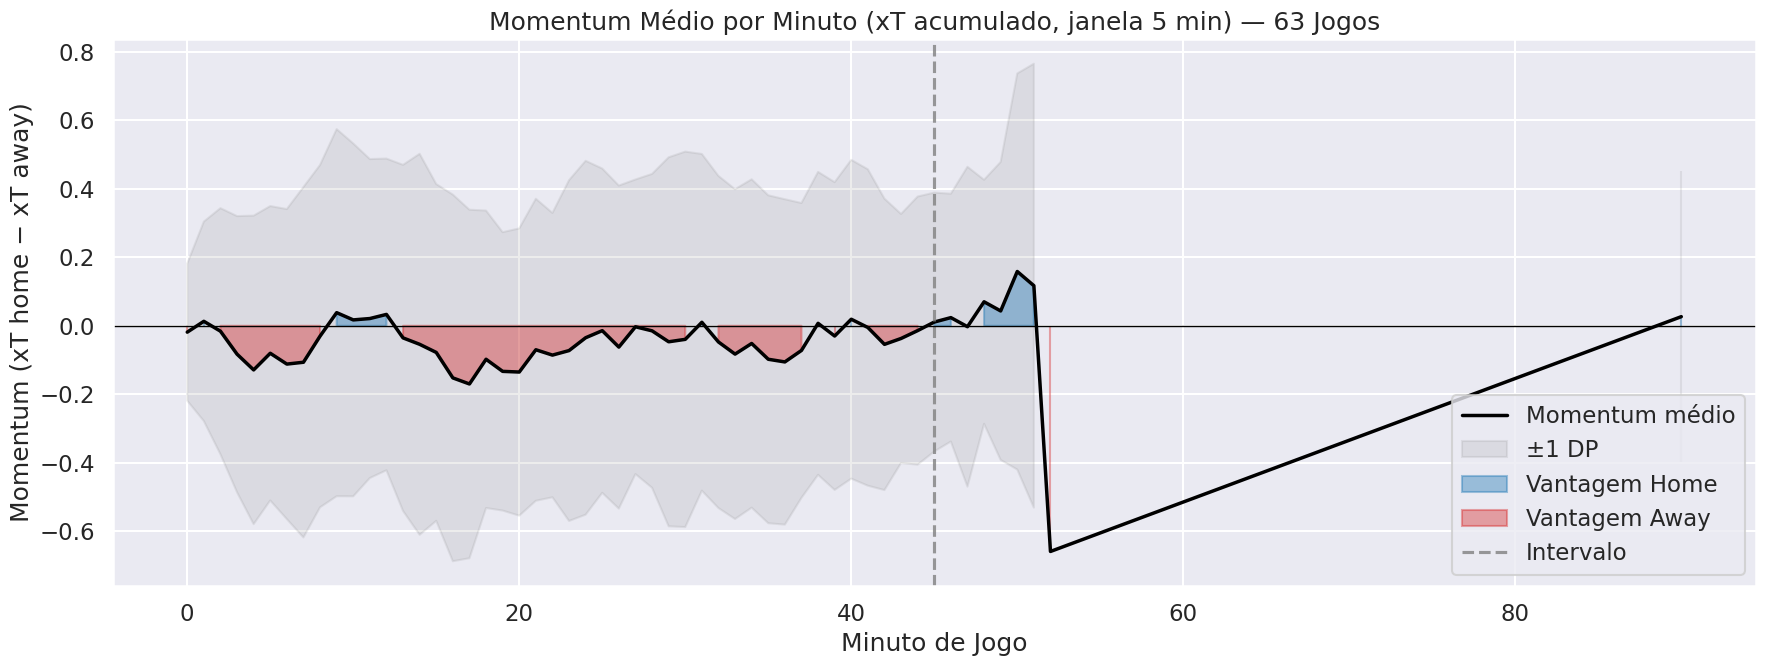

In [16]:
# df_momentum já carregado de data/processed/momentum.parquet
mom_mean = df_momentum.groupby("match_minute")["momentum"].mean()
mom_std  = df_momentum.groupby("match_minute")["momentum"].std()
mask = (mom_mean.index >= 0) & (mom_mean.index <= 90)

fig, ax = plt.subplots(figsize=(18, 7))
x_vals = mom_mean.index[mask]; y_vals = mom_mean.values[mask]; y_std = mom_std.values[mask]
ax.plot(x_vals, y_vals, color="black", lw=2.5, label="Momentum médio")
ax.fill_between(x_vals, y_vals - y_std, y_vals + y_std, alpha=0.15, color="gray", label="±1 DP")
ax.fill_between(x_vals, y_vals, 0, where=(y_vals > 0), color="#1f77b4", alpha=0.4, label="Vantagem Home")
ax.fill_between(x_vals, y_vals, 0, where=(y_vals < 0), color="#d62728", alpha=0.4, label="Vantagem Away")
ax.axvline(45, color="gray", linestyle="--", alpha=0.8, label="Intervalo")
ax.axhline(0, color="black", lw=1)
ax.set_title("Momentum Médio por Minuto (xT acumulado, janela 5 min) — 63 Jogos")
ax.set_xlabel("Minuto de Jogo"); ax.set_ylabel("Momentum (xT home − xT away)")
ax.legend()
plt.tight_layout(); plt.show()

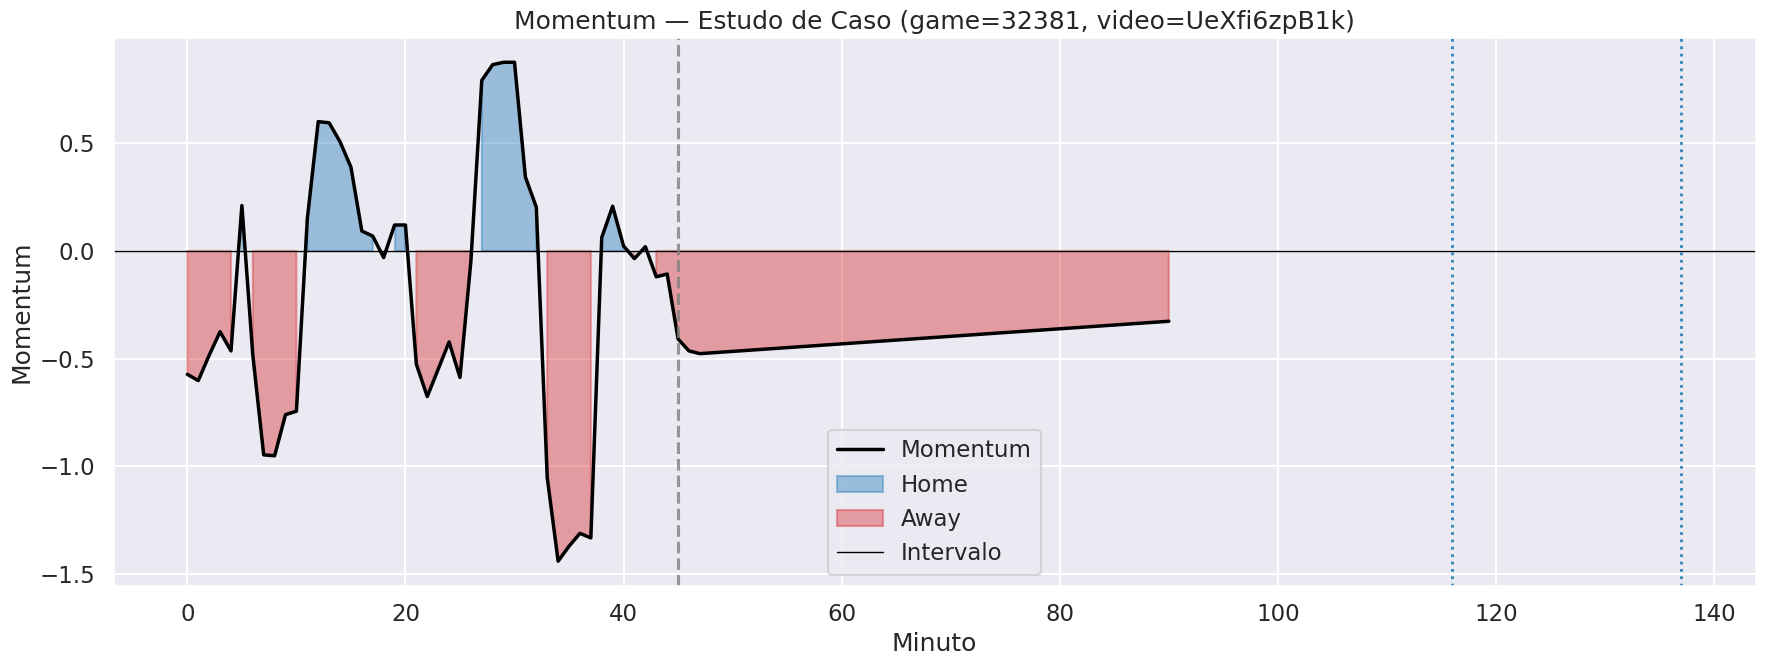

In [17]:
# Estudo de caso: jogo de maior variância de Momentum
top_game_id = df_momentum.groupby('game_id')['momentum'].std().idxmax()
top_vid = [vid for vid, gid in video_mapping.items() if gid == top_game_id]
top_vid_id = top_vid[0] if top_vid else 'N/A'

top_mom = df_momentum[df_momentum['game_id'] == top_game_id].sort_values('match_minute')
mask_top = (top_mom['match_minute'] >= 0) & (top_mom['match_minute'] <= 90)

fig, ax = plt.subplots(figsize=(18, 7))
x_t = top_mom.loc[mask_top, 'match_minute']
y_t = top_mom.loc[mask_top, 'momentum']
ax.plot(x_t, y_t, color='black', lw=2.5)
ax.fill_between(x_t, y_t, 0, where=(y_t > 0), color='#1f77b4', alpha=0.4, label='Home')
ax.fill_between(x_t, y_t, 0, where=(y_t < 0), color='#d62728', alpha=0.4, label='Away')
ax.axhline(0, color='black', lw=1)
ax.axvline(45, color='gray', linestyle='--', alpha=0.8)

# Marca gols
game_goals = df_disc[(df_disc['game_id'] == top_game_id) & (df_disc['event_type'] == 'Gol')]
for _, goal in game_goals.iterrows():
    if goal['match_minute'] is not None:
        color = '#1f77b4' if goal['home_team'] else '#d62728'
        ax.axvline(goal['match_minute'], color=color, linestyle=':', alpha=0.9, lw=2)

ax.set_title(f'Momentum — Estudo de Caso (game={top_game_id}, video={top_vid_id})')
ax.set_xlabel('Minuto'); ax.set_ylabel('Momentum')
ax.legend(['Momentum', 'Home', 'Away', 'Intervalo'])
plt.tight_layout(); plt.show()

### Análise do Momentum e Preparação para as RQs

1. **Padrão Agregado**: O Momentum médio flutua em torno de zero (balanço esperado), com leve vantagem home nos primeiros minutos — consistente com a vantagem do campo em casa.
2. **Estudo de Caso**: No jogo de maior variância, as mudanças de sinal do Momentum frequentemente precedem ou coincidem com gols (linhas pontilhadas), evidenciando que **a pressão de campo precede o evento** — alinhado à hipótese da RQ2.
3. **Eixo Temporal Compartilhado**: Tanto o Momentum quanto as métricas de sentimento (WSI, Seção 5) operam na resolução de **1 minuto de jogo**, permitindo alinhamento direto via `match_minute`.

| Sinal | Resolução | Próximo Passo |
|---|---|---|
| WSI do Chat | 1 min/jogo | RQ1: Cross-correlation WSI × Momentum |
| Momentum (xT) | 1 min/jogo | RQ1 + RQ2 |
| Eventos Discretos (Gols/Cartões) | timestamp exato | RQ2: Janela pré-evento |


## 13. Conclusão Geral

Este notebook estabelece o **framework completo de dados** para as análises das RQs:

| Componente | Métrica | Fonte |
|---|---|---|
| Sentimento do Chat | Polaridade, WSI | YouTube Live Chat (246k msgs, 63 jogos) |
| Perigo de Campo | xT por zona e por minuto | Gradient Events (63 jogos mapeados) |
| Pressão Relativa | Momentum (rolling 5min) | Gradient Events |
| Eventos Discretos | Gols, Cartões, Substituições | Gradient Events |

**Próximos Passos (TP3):**
- **RQ1**: Cross-correlation entre WSI e Momentum por minuto de jogo (Pearson + Dynamic Time Warping).
- **RQ2**: Análise de janelas de sentimento pré-evento (t−5 a t−1 min antes de gols/cartões) via teste de hipótese (Mann-Whitney U).